# 01 · Gradient boosting from scratch

Before using any library, let's build the core idea in ~20 lines so nothing
later is magic.

### The idea
Gradient boosting builds an **additive** model, one small tree at a time. Each
new tree is trained to fix the **errors of the trees so far**. For squared-error
regression the "error to fix" is simply the **residual** $y - \hat{y}$, which is
(minus) the gradient of the loss. We add each tree's contribution scaled by a
small **learning rate** $\eta$ so no single tree dominates:

$$ \hat{y}^{(m)} = \hat{y}^{(m-1)} + \eta \, h_m(x) $$

In [1]:
import os, sys, warnings, time
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))   # make utils/ importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
np.set_printoptions(precision=3, suppress=True)

from utils import data as D
from utils import plotting as P


In [2]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error

# Load cached data and ordinal-encode the category (our scratch model is numeric-only).
df = pd.read_parquet("../data/regression.parquet")
y = df.pop("target")
X = D.encode_categorical(df)
Xtr, Xte, ytr, yte = D.train_test_split_df(X, y, test_size=0.25, seed=0)
Xtr.shape, Xte.shape

((3000, 10), (1000, 10))

In [3]:
class SimpleGBDT:
    """A minimal gradient booster for squared-error regression."""
    def __init__(self, n_estimators=200, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.trees = []

    def fit(self, X, y, eval_set=None):
        self.init_ = float(np.mean(y))          # best constant: the mean
        pred = np.full(len(y), self.init_)
        self.train_rmse_, self.val_rmse_ = [], []
        if eval_set is not None:
            Xv, yv = eval_set
            vpred = np.full(len(yv), self.init_)
        for _ in range(self.n_estimators):
            residual = y.to_numpy() - pred           # = -gradient of 0.5*(y-pred)^2
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, residual)
            pred += self.learning_rate * tree.predict(X)
            self.trees.append(tree)
            self.train_rmse_.append(root_mean_squared_error(y, pred))
            if eval_set is not None:
                vpred += self.learning_rate * tree.predict(Xv)
                self.val_rmse_.append(root_mean_squared_error(yv, vpred))
        return self

    def predict(self, X, n_trees=None):
        pred = np.full(len(X), self.init_)
        for tree in self.trees[:n_trees]:
            pred += self.learning_rate * tree.predict(X)
        return pred

final train RMSE = 1.149
final  val  RMSE = 1.882


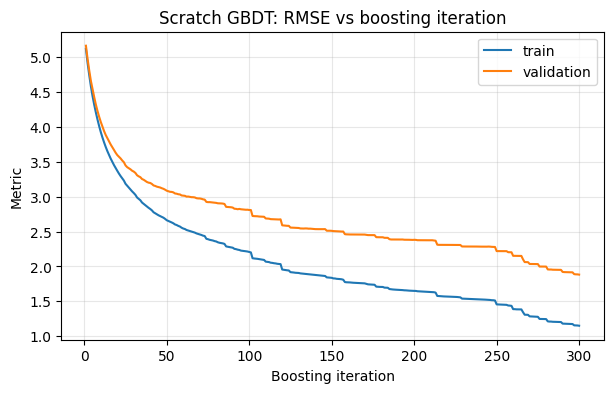

In [4]:
model = SimpleGBDT(n_estimators=300, learning_rate=0.1, max_depth=3)
model.fit(Xtr, ytr, eval_set=(Xte, yte))
print(f"final train RMSE = {model.train_rmse_[-1]:.3f}")
print(f"final  val  RMSE = {model.val_rmse_[-1]:.3f}")

P.plot_training_curve({"train": model.train_rmse_, "validation": model.val_rmse_},
                      title="Scratch GBDT: RMSE vs boosting iteration")
plt.show()

## The learning-rate trade-off

A smaller learning rate needs more trees but usually generalises better. Let's
sweep it.

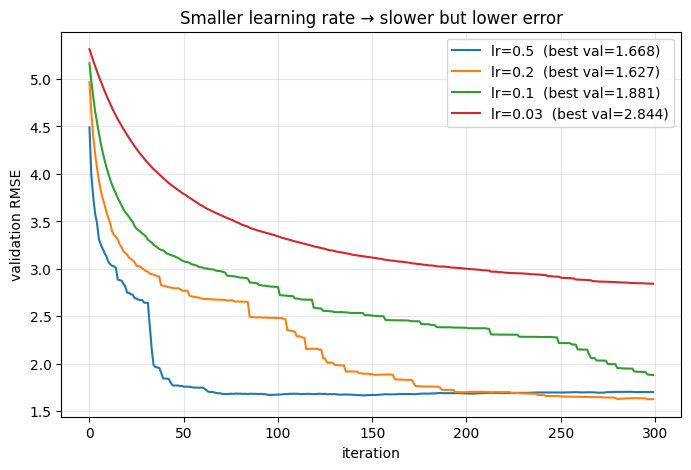

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for lr in [0.5, 0.2, 0.1, 0.03]:
    m = SimpleGBDT(n_estimators=300, learning_rate=lr, max_depth=3)
    m.fit(Xtr, ytr, eval_set=(Xte, yte))
    ax.plot(m.val_rmse_, label=f"lr={lr}  (best val={min(m.val_rmse_):.3f})")
ax.set(xlabel="iteration", ylabel="validation RMSE",
       title="Smaller learning rate → slower but lower error")
ax.legend(); ax.grid(alpha=0.3); plt.show()

## Watching the prediction build up

For a single test point, see the prediction crawl toward the truth as trees are
added - the essence of *additive* modelling.

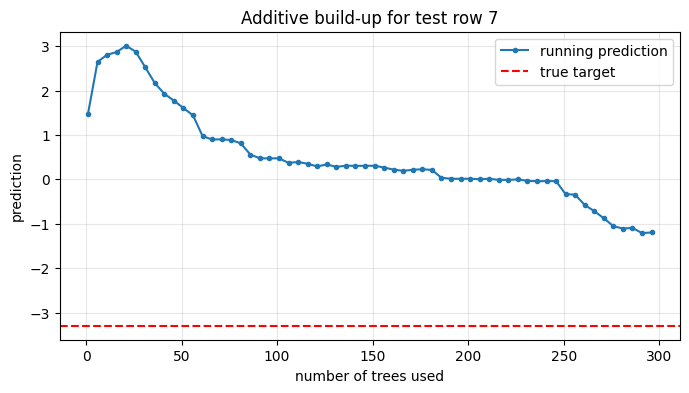

In [6]:
i = 7  # an arbitrary test row
stages = range(1, len(model.trees)+1, 5)
traj = [model.predict(Xte.iloc[[i]], n_trees=k)[0] for k in stages]
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(list(stages), traj, marker="o", ms=3, label="running prediction")
ax.axhline(yte.iloc[i], color="r", ls="--", label="true target")
ax.set(xlabel="number of trees used", ylabel="prediction",
       title=f"Additive build-up for test row {i}")
ax.legend(); ax.grid(alpha=0.3); plt.show()

## What the real libraries add

Our toy works, but production libraries add a lot on top:

| Concept | Scratch | Real libraries |
|---|---|---|
| Loss | squared error only | any differentiable loss |
| Gradient info | 1st-order (residual) | XGBoost uses **2nd-order** (Hessian) |
| Regularization | depth only | leaf penalties, shrinkage, subsampling |
| Speed | retrain on all data | **histogram** binning, GPU |
| Categoricals | manual encoding | native (CatBoost/LightGBM) |
| Tree shape | level-wise | leaf-wise (LGB), symmetric (CatBoost) |

Next: **`02_xgboost`**.